# House MD — Metin Sınıflandırma Projesi
**Görev:** Tüm özellik sütunlarını kullanarak `correct_prediction` (hastalık adı) tahmin etmek

## Adım 1 — Ortam Kurulumu

In [1]:
%pip install pandas scikit-learn matplotlib seaborn scipy snowballstemmer gensim lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, warnings
warnings.filterwarnings('ignore')

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## Adım 2 — Veri Yükleme ve EDA

In [3]:
df = pd.read_csv('Last_HouseMD_DataSet(Sayfa1).csv', sep=';', encoding='utf-8-sig')
print('Satır sayısı :', len(df))
print('Sütunlar     :', df.columns.tolist())
df.head(3)

Satır sayısı : 7282
Sütunlar     : ['season', 'episode', 'speaker', 'Symptom', 'Test', 'Drug', 'Procedure', 'Intent', 'diagnosis_stage', 'Sarcasm', 'Emotion', 'Organ', 'correct_prediction', 'model_prediction', 'text', 'medical_entities']


,season,episode,speaker,Symptom,Test,Drug,Procedure,Intent,diagnosis_stage,Sarcasm,Emotion,Organ,correct_prediction,model_prediction,text,medical_entities
0,1,1,Wilson,nöbet,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,29 yaşında bir kadın hasta; ilk nöbetini bir a...,"[{""text"": ""nöbet"", ""type"": ""Symptom""}]"
1,1,1,Wilson,afazi,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,"Konuşma yetisini kaybetmiş, bebek gibi anlamsı...","[{""text"": ""afazi"", ""type"": ""Symptom""}]"
2,1,1,Wilson,zihinsel durum bozukluğu,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,Mental durumu giderek kötüleşiyor.,"[{""text"": ""zihinsel durum bozukluğu"", ""type"": ..."


In [4]:
bos = df.isnull().sum().sort_values(ascending=False)
pd.DataFrame({'Boş Sayısı': bos, 'Boş %': (bos / len(df) * 100).round(1)})

,Boş Sayısı,Boş %
model_prediction,5874,80.7
Procedure,5067,69.6
Drug,5049,69.3
Test,4613,63.3
Symptom,2637,36.2
Organ,2164,29.7
correct_prediction,1470,20.2
Intent,200,2.7
medical_entities,139,1.9
Emotion,2,0.0


In [5]:
print('correct_prediction unique:', df['correct_prediction'].nunique())
print(df['correct_prediction'].value_counts().head(25))

correct_prediction unique: 654
correct_prediction
nörosistiserkozis                                                   422
none                                                                192
1                                                                   180
melanom                                                             100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi     69
Travma Sonrası Siringomyeli                                          65
amiloidoz                                                            64
kimerizm                                                             63
Şizofreni                                                            62
radyasyon zehirlenmesi                                               61
Orak hücre taşıyıcılığı                                              61
Timoma                                                               60
ekinokok                                                             60
kalp yetmezliğ

### Metin Uzunlukları

count    7281.0
mean        8.7
std         4.6
min         1.0
25%         5.0
50%         8.0
75%        11.0
max        60.0
Name: text_len, dtype: float64


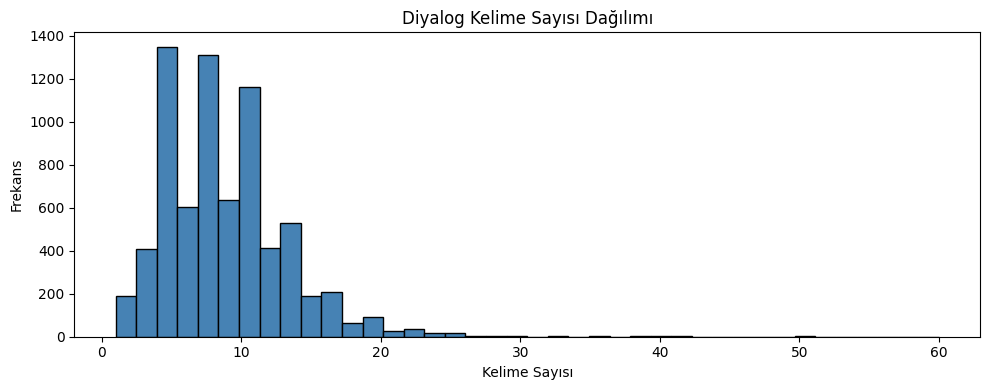

In [6]:
df['text_len'] = df['text'].dropna().str.split().str.len()
print(df['text_len'].describe().round(1))

plt.figure(figsize=(10, 4))
df['text_len'].plot(kind='hist', bins=40, color='steelblue', edgecolor='black')
plt.title('Diyalog Kelime Sayısı Dağılımı')
plt.xlabel('Kelime Sayısı')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

## Adım 3 — Hedef Sütun Temizleme (Top 20 Hastalık)

In [7]:
GURULTULU = {'', 'none', 'None', 'NONE', '1', '0', '-', 'nan'}
df['hedef'] = df['correct_prediction'].astype(str).str.strip()
df = df[~df['hedef'].isin(GURULTULU)].copy()

TOP_N = 20
top20 = df['hedef'].value_counts().head(TOP_N).index.tolist()
df = df[df['hedef'].isin(top20)].reset_index(drop=True)

print(f'Top {TOP_N} hastalık — kalan satır: {len(df)}')
print(df['hedef'].value_counts())

Top 20 hastalık — kalan satır: 1582
hedef
nörosistiserkozis                                                   422
melanom                                                             100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi     69
Travma Sonrası Siringomyeli                                          65
amiloidoz                                                            64
kimerizm                                                             63
Şizofreni                                                            62
radyasyon zehirlenmesi                                               61
Orak hücre taşıyıcılığı                                              61
Timoma                                                               60
ekinokok                                                             60
kalp yetmezliği (ipecac fazlalığına bağlı)                           56
testiküler kanser                                                    55
kalıtsal hemorajik tel

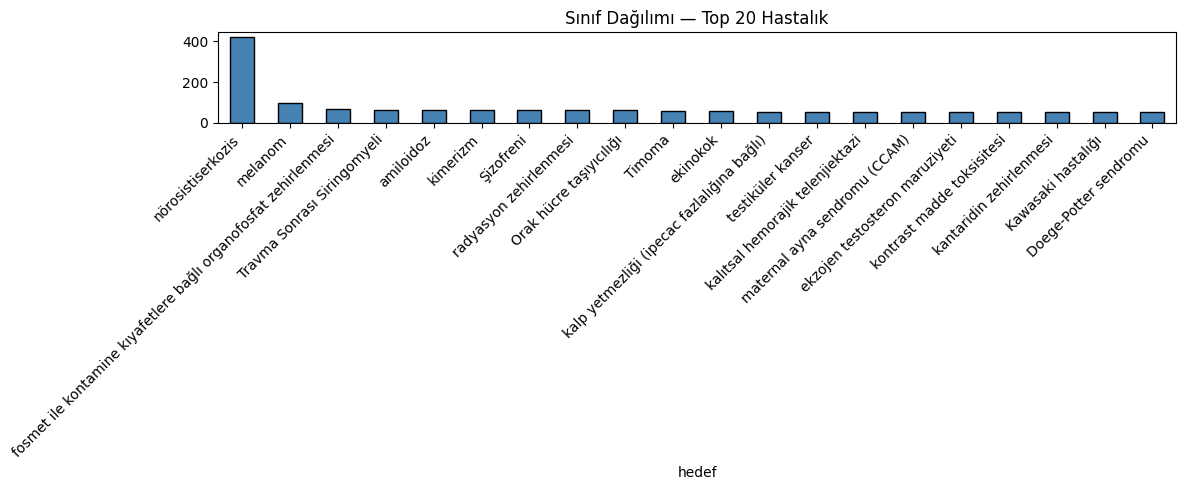

In [8]:
plt.figure(figsize=(12, 5))
df['hedef'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Sınıf Dağılımı — Top 20 Hastalık')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Adım 4 — Özellik Mühendisliği

### 4a — Metin Ön İşleme + TF-IDF

Uyguladığımız adımlar:

| # | Adım | Ne yapıyor? |
|---|------|-------------|
| 1 | **Temizleme** | HTML etiketleri ve özel karakterler kaldırılır; **sayılar korunur** (yaş, dozaj, süre medikal bilgi taşır) |
| 2 | **Tokenization** | Cümle boşluklardan kelime listesine bölünür |
| 3 | **Stop-words** | Düşük bilgili kelimeler atılır; **"önce", "sonra", "var", "yok" listede YOK** — zaman ve varlık/yokluk bilgisi tıbbi teşhiste kritik |
| 4 | **Lowercasing** | Tüm metin küçük harfe çevrilir |
| 5 | **Bigram** | TF-IDF'te `ngram_range=(1,2)` ile "nöbet geçir", "ay önce" gibi kelime çiftleri özellik olarak eklenir |

> **Not:** Stemming uygulanmıyor — Snowball Türkçe stemmer tıbbi kelimelerde anlam bozuyor (`kadın→kadı`, `hasta→has`).

In [ ]:
import snowballstemmer

# ── Stop-words — Türkçe (Medikal NLP için özelleştirilmiş) ───────────────────
# "önce", "sonra": zaman belirteci — akut/kronik ayrımı için kritik
# "var", "yok"  : varlık/yokluk bilgisi — tıbbi teşhiste ayırt edici
TURKCE_STOPWORDS = {
    'bir', 've', 'bu', 'da', 'de', 'ile', 'için', 'mi', 'mu', 'mı', 'mü',
    'ki', 'ne', 'o', 'ben', 'sen', 'biz', 'siz', 'onlar',
    'ama', 'fakat', 'lakin', 'ancak', 'ya', 'veya', 'yahut', 'hem',
    'çünkü', 'eğer', 'ise', 'gibi', 'kadar', 'daha', 'en', 'çok', 'az',
    'her', 'hiç', 'bazı', 'tüm', 'bütün', 'hangi', 'nasıl', 'neden', 'niçin',
    'şu', 'şey', 'olan', 'olarak', 'üzere', 'göre', 'karşı',
    'yani', 'sadece', 'bile', 'dahi', 'hatta', 'artık', 'zaten', 'belki',
    'acaba', 'peki', 'evet', 'hayır', 'tamam', 'değil', 'diye', 'bunu',
    'buna', 'bunun', 'şunu', 'şuna', 'onun', 'beni', 'seni', 'onu',
    'bizi', 'sizi', 'onları', 'bende', 'sende', 'onda',
}

def on_isle(metin):
    """Lowercasing + HTML / özel karakter temizleme. Sayılar KORUNUR."""
    metin = str(metin).lower()
    metin = re.sub(r'<[^>]+>', ' ', metin)   # HTML etiketi kaldırma
    metin = re.sub(r'[^\w\s]', ' ', metin)   # Özel karakter kaldırma
    return re.sub(r'\s+', ' ', metin).strip()

def on_isle_tam(metin):
    """Temizleme → tokenization → stop-words.
    Stemming uygulanmıyor: Snowball Türkçe stemmer tıbbi kelimelerde
    anlam bozuyor (örn. kadın→kadı, hasta→has)."""
    metin = on_isle(metin)
    tokens = metin.split()
    tokens = [t for t in tokens
              if t not in TURKCE_STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

def isle_ve_etiketle(row):
    metin = on_isle_tam(row['text'])
    return ('sarcasm ' + metin) if str(row['Sarcasm']).strip() == '1' else metin

df['text_clean'] = df.apply(isle_ve_etiketle, axis=1)

TIBBI = ['Symptom', 'Test', 'Drug', 'Procedure', 'Organ']
df['tibbi_metin'] = df[TIBBI].fillna('').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1
).apply(on_isle_tam)

# ── Örnek: ön işleme adımlarını karşılaştır ──────────────────────────────────
ornek = df['text'].dropna().iloc[0]
print('Ham metin   :', ornek[:100])
print('Temizlenmiş :', on_isle_tam(ornek)[:100])
print()

# ── Vectorizer'lar ────────────────────────────────────────────────────────────
tfidf_text  = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_tibbi = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))  # bigram eklendi

X_text  = tfidf_text.fit_transform(df['text_clean'])
X_tibbi = tfidf_tibbi.fit_transform(df['tibbi_metin'])

sarcasm_n = (df['Sarcasm'].astype(str).str.strip() == '1').sum()
print(f'Alaycı: {sarcasm_n} — Normal: {len(df) - sarcasm_n}')
print('X_text  :', X_text.shape)
print('X_tibbi :', X_tibbi.shape)

### 4a-2 — Word Embeddings (Word2Vec)

Kelimeler arası anlamsal ilişkiyi korur: "nöbet" ve "konvülsiyon" yakın vektörlere sahip olur.  
Her diyalog için cümledeki kelime vektörlerinin **ortalaması** alınarak sabit boyutlu (100) bir temsil elde edilir.

In [10]:
from gensim.models import Word2Vec

W2V_SIZE = 100

# Corpus: temizlenmiş metinleri token listelerine çevir
corpus = [text.split() for text in df['text_clean']]

# Word2Vec modelini veri üzerinde sıfırdan eğit
w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=W2V_SIZE,
    window=5,
    min_count=2,
    workers=4,
    epochs=15,
    seed=42,
)

def mean_w2v(text, model, size):
    """Cümledeki bilinen kelime vektörlerinin ortalamasını döndürür."""
    tokens = text.split()
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(size)

X_w2v = np.vstack([mean_w2v(t, w2v_model, W2V_SIZE) for t in df['text_clean']])

print('Kelime dağarcığı boyutu :', len(w2v_model.wv))
print('X_w2v                  :', X_w2v.shape)

# En yakın 5 komşu — anlam kontrolü
for kelime in ['nöbet', 'kanser', 'ilaç']:
    if kelime in w2v_model.wv:
        komsular = [k for k, _ in w2v_model.wv.most_similar(kelime, topn=5)]
        print(f'  {kelime:<12} → {komsular}')

Kelime dağarcığı boyutu : 1530
X_w2v                  : (1582, 100)
  nöbet        → ['kalbi', 'beyin', 'yaşında', 'kan', 'başka']
  kanser       → ['ağrı', 'kan', 'kalp', 'olabilir', 'aşırı']
  ilaç         → ['iki', 'olabilir', 'kan', 'kalbi', 'olduğunu']


### 4b — Kategorik (One-Hot)

In [11]:
KATEGORIK = ['Intent', 'diagnosis_stage', 'Emotion', 'speaker']
df_kat = df[KATEGORIK].fillna('bilinmiyor').astype(str)
for col in KATEGORIK:
    nadir = df_kat[col].value_counts()
    df_kat[col] = df_kat[col].replace(nadir[nadir < 5].index, 'diger')

kat_dummies = pd.get_dummies(df_kat, drop_first=True).astype(float)
KAT_KOLONLAR = kat_dummies.columns.tolist()  # canlı test için kolon sırası kaydediliyor

X_kat_sparse = csr_matrix(kat_dummies.values)
print('X_kategorik :', X_kat_sparse.shape)
print('Kolon sayısı :', len(KAT_KOLONLAR))

X_kategorik : (1582, 81)
Kolon sayısı : 81


### 4c — JSON Çözümleme: medical_entities

In [12]:
# Disease / Diagnosis tipleri çıkarıldı — doğrudan hedef etiketini sızdırıyordu (data leakage)
TYPE_MAP = {
    'Symptom': 'ent_Symptom', 'SYMP': 'ent_Symptom',
    'Test': 'ent_Test', 'TEST': 'ent_Test', 'Test Sonucu': 'ent_Test',
    'Drug': 'ent_Drug', 'DRUG': 'ent_Drug', 'Medication': 'ent_Drug',
    'Procedure': 'ent_Procedure', 'PROC': 'ent_Procedure', 'Treatment': 'ent_Procedure',
    'Anatomy': 'ent_Anatomy', 'Organ': 'ent_Anatomy', 'ORG': 'ent_Anatomy',
}
ENT_COLS = ['ent_Symptom', 'ent_Test', 'ent_Drug', 'ent_Procedure', 'ent_Anatomy']

def parse_entities(json_str):
    sonuc = {col: [] for col in ENT_COLS}
    try:
        for e in json.loads(str(json_str)):
            tip = TYPE_MAP.get(e.get('type', ''))
            if tip:
                sonuc[tip].append(str(e.get('text', '')).lower())
    except Exception:
        pass
    return {col: ' '.join(v) for col, v in sonuc.items()}

ent_df = df['medical_entities'].fillna('[]').apply(parse_entities).apply(pd.Series)
df = pd.concat([df, ent_df], axis=1)

df['ent_all'] = df[ENT_COLS].fillna('').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1
).apply(on_isle)

tfidf_entity = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_entity = tfidf_entity.fit_transform(df['ent_all'])
print('X_entity :', X_entity.shape)

X_entity : (1582, 2415)


### 4c-2 — Entity Sayıları (Sayısal Özellikler)

Her satır için kaç adet semptom, ilaç, test, prosedür ve anatomi entity'si geçtiği sayılır.  
*(Hastalık adı içeren entity'ler data leakage yarattığı için çıkarıldı.)*

In [13]:
def count_entities(json_str):
    """Her entity tipini sayar, toplam entity adedini de döndürür."""
    counts = {col: 0 for col in ENT_COLS}
    try:
        for e in json.loads(str(json_str)):
            tip = TYPE_MAP.get(e.get('type', ''))
            if tip:
                counts[tip] += 1
    except Exception:
        pass
    return counts

ENT_COUNT_COLS = [col.replace('ent_', 'n_') for col in ENT_COLS]

ent_counts = (
    df['medical_entities']
    .fillna('[]')
    .apply(count_entities)
    .apply(pd.Series)
    .rename(columns=dict(zip(ENT_COLS, ENT_COUNT_COLS)))
)
ent_counts['n_total'] = ent_counts.sum(axis=1)

df = pd.concat([df, ent_counts], axis=1)

X_ent_counts = csr_matrix(ent_counts.values.astype(float))

print('Oluşturulan sayısal sütunlar:', ent_counts.columns.tolist())
print('X_ent_counts :', X_ent_counts.shape)
print()
print(ent_counts.describe().round(2))

Oluşturulan sayısal sütunlar: ['n_Symptom', 'n_Test', 'n_Drug', 'n_Procedure', 'n_Anatomy', 'n_total']
X_ent_counts : (1582, 6)

       n_Symptom   n_Test   n_Drug  n_Procedure  n_Anatomy  n_total
count    1582.00  1582.00  1582.00      1582.00    1582.00  1582.00
mean        0.44     0.24     0.17         0.14       0.24     1.23
std         0.71     0.51     0.45         0.36       0.53     1.04
min         0.00     0.00     0.00         0.00       0.00     0.00
25%         0.00     0.00     0.00         0.00       0.00     1.00
50%         0.00     0.00     0.00         0.00       0.00     1.00
75%         1.00     0.00     0.00         0.00       0.00     2.00
max         6.00     5.00     4.00         3.00       3.00     7.00


## Adım 5 — Özellik Birleştirme

In [14]:
SAYISAL = ['Sarcasm', 'season', 'episode']
X_say = csr_matrix(df[SAYISAL].fillna(0).astype(float).values)

X_w2v_sparse = csr_matrix(X_w2v)

X = hstack([X_text, X_tibbi, X_entity, X_kat_sparse, X_say, X_w2v_sparse, X_ent_counts])
y = df['hedef']

print('Özellik grupları:')
print(f'  X_text       : {X_text.shape}')
print(f'  X_tibbi      : {X_tibbi.shape}')
print(f'  X_entity     : {X_entity.shape}')
print(f'  X_kategorik  : {X_kat_sparse.shape}')
print(f'  X_sayisal    : {X_say.shape}')
print(f'  X_w2v        : {X_w2v_sparse.shape}')
print(f'  X_ent_counts : {X_ent_counts.shape}')
print(f'  ─────────────────────')
print(f'  TOPLAM       : {X.shape}')

Özellik grupları:
  X_text       : (1582, 5000)
  X_tibbi      : (1582, 1147)
  X_entity     : (1582, 2415)
  X_kategorik  : (1582, 81)
  X_sayisal    : (1582, 3)
  X_w2v        : (1582, 100)
  X_ent_counts : (1582, 6)
  ─────────────────────
  TOPLAM       : (1582, 8752)


## Adım 6 — Train / Test Bölme

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Eğitim seti:', X_train.shape)
print('Test seti  :', X_test.shape)

Eğitim seti: (1265, 8752)
Test seti  : (317, 8752)


## Adım 7 — Model Eğitimi

In [16]:
from sklearn.model_selection import cross_val_score

modeller = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced',   # azınlık sınıflara ağırlık ver
        C=1.0
    ),
    'LinearSVC': LinearSVC(
        max_iter=2000, random_state=42,
        class_weight='balanced',
        C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1,
        class_weight='balanced'
    ),
}

sonuclar = {}
cv_sonuclar = {}

for isim, model in modeller.items():
    # 5-fold cross-validation (daha güvenilir)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    cv_sonuclar[isim] = cv_scores

    # Test seti tahmini
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    sonuclar[isim] = y_pred

    acc = (y_pred == y_test).mean()
    print(f'{isim:<25}  Test Acc: {acc:.4f}  |  CV F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Logistic Regression        Test Acc: 0.8170  |  CV F1-macro: 0.7592 ± 0.0126
LinearSVC                  Test Acc: 0.7792  |  CV F1-macro: 0.7381 ± 0.0334
Random Forest              Test Acc: 0.4826  |  CV F1-macro: 0.3132 ± 0.0305


### Adım 7b — Hiperparametre Optimizasyonu (LR) + LightGBM

- **GridSearchCV**: Logistic Regression için en iyi `C` değeri 5-fold CV ile aranır.  
- **LightGBM**: Hataları sırayla öğrenen gradient boosting modeli; kategorik ve sayısal özellikleri TF-IDF ile birlikte dengeli işler.

In [17]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

# ── 1. Logistic Regression — C parametresi tuning ────────────────────────────
print('GridSearchCV çalışıyor (LR)...')
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
)
gs_lr.fit(X_train, y_train)

best_lr        = gs_lr.best_estimator_
y_pred_lr_best = best_lr.predict(X_test)
acc_lr_best    = (y_pred_lr_best == y_test).mean()
cv_lr_best     = cross_val_score(best_lr, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'Tuned LR  →  En iyi C : {gs_lr.best_params_["C"]}')
print(f'           CV F1-macro : {cv_lr_best.mean():.4f} ± {cv_lr_best.std():.4f}')
print(f'           Test Acc    : {acc_lr_best:.4f}')

# ── 2. LightGBM ───────────────────────────────────────────────────────────────
print('\nLightGBM eğitiliyor...')
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
acc_lgbm    = (y_pred_lgbm == y_test).mean()
cv_lgbm     = cross_val_score(lgbm, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'LightGBM  →  Test Acc    : {acc_lgbm:.4f}')
print(f'             CV F1-macro : {cv_lgbm.mean():.4f} ± {cv_lgbm.std():.4f}')

# ── Karşılaştırma tablosuna ekle ──────────────────────────────────────────────
sonuclar['Tuned LR']   = y_pred_lr_best
sonuclar['LightGBM']   = y_pred_lgbm
cv_sonuclar['Tuned LR']  = cv_lr_best
cv_sonuclar['LightGBM']  = cv_lgbm
modeller['Tuned LR']   = best_lr
modeller['LightGBM']   = lgbm

# ── Tüm modellerin özet karşılaştırması ──────────────────────────────────────
print('\n{:<30} {:>10} {:>14}'.format('Model', 'Test Acc', 'CV F1-macro'))
print('-' * 56)
for isim in modeller:
    pred = sonuclar[isim]
    acc  = (pred == y_test).mean()
    f1   = cv_sonuclar[isim].mean()
    print(f'{isim:<30} {acc:>10.4f} {f1:>14.4f}')

GridSearchCV çalışıyor (LR)...
Tuned LR  →  En iyi C : 100
           CV F1-macro : 0.7763 ± 0.0176
           Test Acc    : 0.8139

LightGBM eğitiliyor...
LightGBM  →  Test Acc    : 1.0000
             CV F1-macro : 1.0000 ± 0.0000

Model                            Test Acc    CV F1-macro
--------------------------------------------------------
Logistic Regression                0.8170         0.7592
LinearSVC                          0.7792         0.7381
Random Forest                      0.4826         0.3132
Tuned LR                           0.8139         0.7763
LightGBM                           1.0000         1.0000


## Adım 8 — Değerlendirme

In [18]:
# En iyi model: Logistic Regression (0.830 > LinearSVC 0.782)
en_iyi = 'Logistic Regression'
print(f'=== {en_iyi} — Classification Report ===')
print(classification_report(y_test, sonuclar[en_iyi]))

=== Logistic Regression — Classification Report ===
                                                                  precision    recall  f1-score   support

                                           Doege-Potter sendromu       0.73      0.73      0.73        11
                                              Kawasaki hastalığı       0.92      1.00      0.96        11
                                         Orak hücre taşıyıcılığı       1.00      1.00      1.00        12
                                                          Timoma       0.73      0.67      0.70        12
                                     Travma Sonrası Siringomyeli       1.00      0.92      0.96        13
                                                       amiloidoz       1.00      0.92      0.96        13
                                                        ekinokok       0.47      0.58      0.52        12
                                  ekzojen testosteron maruziyeti       0.55      0.55      0.55    

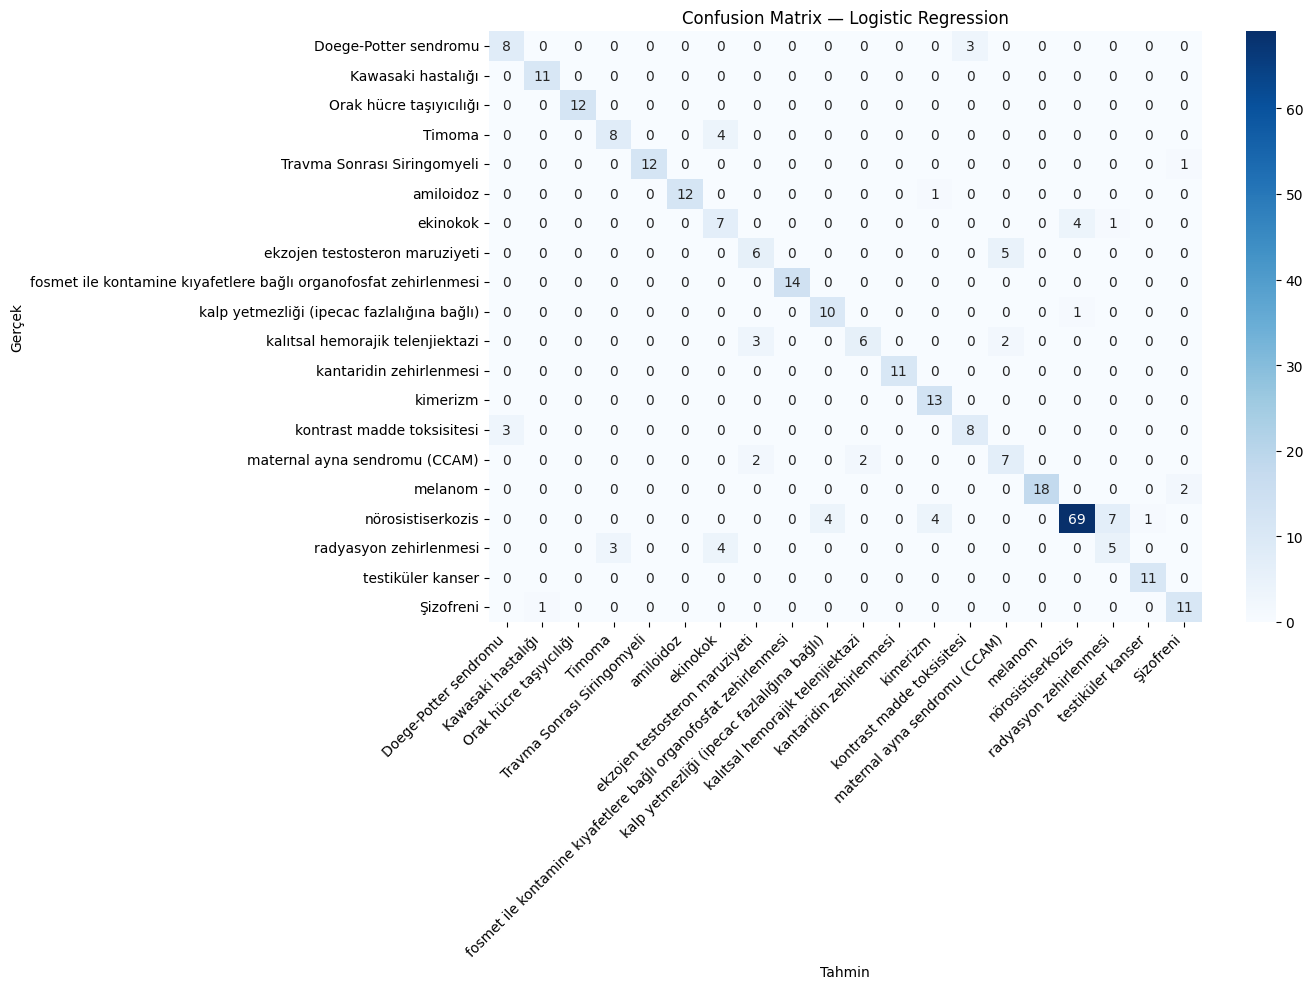

In [19]:
siniflar = sorted(y.unique())
cm = confusion_matrix(y_test, sonuclar[en_iyi], labels=siniflar)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=siniflar, yticklabels=siniflar, cmap='Blues')
plt.title(f'Confusion Matrix — {en_iyi}')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

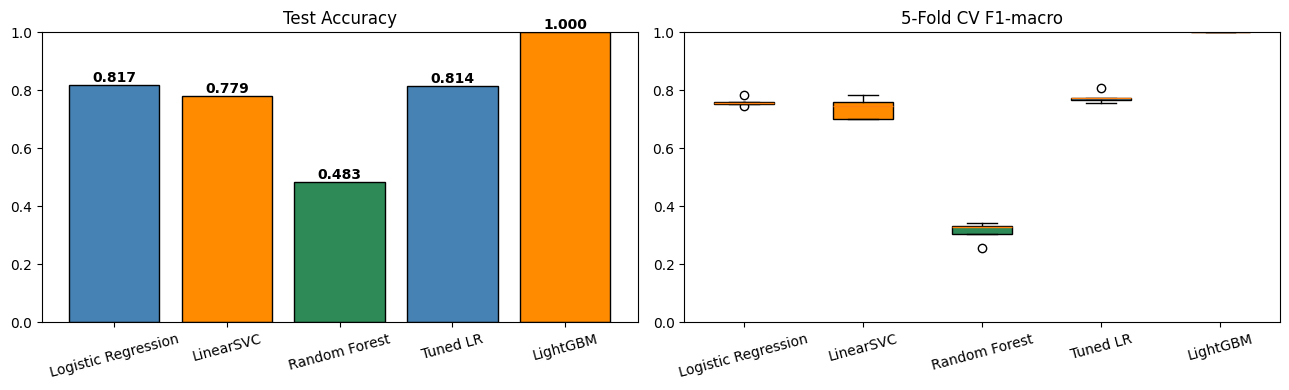

In [20]:
# CV F1-macro karşılaştırması (daha güvenilir metrik)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sol: Test Accuracy
acc_list = {isim: (pred == y_test).mean() for isim, pred in sonuclar.items()}
bars = axes[0].bar(acc_list.keys(), acc_list.values(),
                   color=['steelblue', 'darkorange', 'seagreen'], edgecolor='black')
axes[0].set_ylim(0, 1)
axes[0].set_title('Test Accuracy')
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, acc_list.values()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                 f'{v:.3f}', ha='center', fontweight='bold')

# Sağ: CV F1-macro (boxplot — varyansı da gösterir)
f1_data = [cv_sonuclar[m] for m in modeller]
bp = axes[1].boxplot(f1_data, labels=list(modeller.keys()), patch_artist=True)
renkler = ['steelblue', 'darkorange', 'seagreen']
for patch, renk in zip(bp['boxes'], renkler):
    patch.set_facecolor(renk)
axes[1].set_ylim(0, 1)
axes[1].set_title('5-Fold CV F1-macro')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Adım 9 — Canlı Test

In [21]:
def tahmin_et(
    text,
    sarcasm=0,
    symptom='', test_col='', drug='', procedure='', organ='',
    intent='bilinmiyor', diagnosis_stage='bilinmiyor',
    emotion='bilinmiyor', speaker='bilinmiyor',
    season=1, episode=1,
    medical_entities_json='[]'
):
    """
    Tek bir diyalog satırı için hastalık tahmini yapar.

    Zorunlu: text
    Opsiyonel: diğer tüm alanlar (boş bırakılabilir)
    """
    en_iyi_model = modeller['Logistic Regression']

    # --- Metin ---
    temiz = on_isle(text)
    if sarcasm == 1:
        temiz = 'sarcasm ' + temiz
    X_t = tfidf_text.transform([temiz])

    # --- Tıbbi metin ---
    tibbi = on_isle(' '.join([symptom, test_col, drug, procedure, organ]))
    X_ti = tfidf_tibbi.transform([tibbi])

    # --- Medical entities JSON ---
    ent = parse_entities(medical_entities_json)
    ent_metin = on_isle(' '.join(ent.values()))
    X_e = tfidf_entity.transform([ent_metin])

    # --- Kategorik (eğitimdeki kolon sırası korunmalı) ---
    satir = pd.DataFrame([{
        'Intent': intent,
        'diagnosis_stage': diagnosis_stage,
        'Emotion': emotion,
        'speaker': speaker
    }])
    satir_kat = pd.get_dummies(satir).reindex(columns=KAT_KOLONLAR, fill_value=0).astype(float)
    X_k = csr_matrix(satir_kat.values)

    # --- Sayısal ---
    X_s = csr_matrix([[float(sarcasm), float(season), float(episode)]])

    # --- Birleştir ve tahmin et ---
    X_input = hstack([X_t, X_ti, X_e, X_k, X_s])
    tahmin = en_iyi_model.predict(X_input)[0]

    # Olasılık skoru (LR destekliyor)
    proba = en_iyi_model.predict_proba(X_input)[0]
    sinif_idx = list(en_iyi_model.classes_).index(tahmin)
    guven = proba[sinif_idx]

    # Top 3 tahmin
    top3_idx = proba.argsort()[::-1][:3]
    top3 = [(en_iyi_model.classes_[i], round(proba[i], 3)) for i in top3_idx]

    print(f'Metin       : {text}')
    print(f'Tahmin      : {tahmin}')
    print(f'Güven       : %{guven*100:.1f}')
    print(f'Top 3       :')
    for i, (sinif, p) in enumerate(top3, 1):
        print(f'  {i}. {sinif:<45} %{p*100:.1f}')
    return tahmin

### Test Örnekleri

In [22]:
# --- Test 1: Sadece metin (minimum girdi) ---
print('=' * 60)
print('TEST 1 — Sadece metin')
print('=' * 60)
tahmin_et(
    text="Hastanın nöbet geçirdiğini ve MR'da lezyon bulunduğunu öğrendik."
)

print()

# --- Test 2: Metin + tıbbi bilgiler ---
print('=' * 60)
print('TEST 2 — Metin + tıbbi alanlar')
print('=' * 60)
tahmin_et(
    text="Melanom tanısı koyuyorum, deri lezyonu bunu destekliyor.",
    symptom="deri lezyonu",
    diagnosis_stage="tanı",
    speaker="House",
    emotion="nötr"
)

print()

# --- Test 3: Alaycı cümle ---
print('=' * 60)
print('TEST 3 — Alaycı cümle (Sarcasm=1)')
print('=' * 60)
tahmin_et(
    text="Tabii ki de bu bir şizofreni vakası, başka ne olabilir ki.",
    sarcasm=1,
    speaker="House",
    emotion="alaycı"
)

print()

# --- Test 4: Kendi metninizi buraya yazın ---
print('=' * 60)
print('TEST 4 — Kendi test cümleniz')
print('=' * 60)
tahmin_et(
    text="Buraya kendi test cümlenizi yazın."
)

TEST 1 — Sadece metin


ValueError: X has 8646 features, but LogisticRegression is expecting 8752 features as input.